In [1]:
"""
Componentes conectados y propiedades de región
Este notebook presenta el etiquetado de componentes conectados y las mediciones basadas en regiones en imágenes binarias.
Tras el thresholding y la morphological clean up, el siguiente paso en muchos procesos de segmentación es identificar objetos individuales y cuantificar sus propiedades.
Objetivos de aprendizaje
- Comprender el etiquetado de componentes conectados
- Separar una máscara binaria en regiones individuales
- Medir propiedades de región como área, centroide, cuadro delimitador y descriptores de forma
- Visualizar regiones etiquetadas
- Convertir objetos segmentados en datos cuantitativos
Contexto de imagen de objetos
Los componentes conectados y las propiedades de región son esenciales en la imagen para:
- Conteo de partículas
- Análisis de poros
- Medición de la distribución de tamaño
- Filtrado de objetos
- Extracción de características para aprendizaje automático
"""

'\nComponentes conectados y propiedades de región\nEste notebook presenta el etiquetado de componentes conectados y las mediciones basadas en regiones en imágenes binarias.\nTras el thresholding y la morphological clean up, el siguiente paso en muchos procesos de segmentación es identificar objetos individuales y cuantificar sus propiedades.\nObjetivos de aprendizaje\n- Comprender el etiquetado de componentes conectados\n- Separar una máscara binaria en regiones individuales\n- Medir propiedades de región como área, centroide, cuadro delimitador y descriptores de forma\n- Visualizar regiones etiquetadas\n- Convertir objetos segmentados en datos cuantitativos\nContexto de imagen de objetos\nLos componentes conectados y las propiedades de región son esenciales en la imagen para:\n- Conteo de partículas\n- Análisis de poros\n- Medición de la distribución de tamaño\n- Filtrado de objetos\n- Extracción de características para aprendizaje automático\n'

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, filters, morphology, measure, color, segmentation, util
from skimage.draw import disk

In [3]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

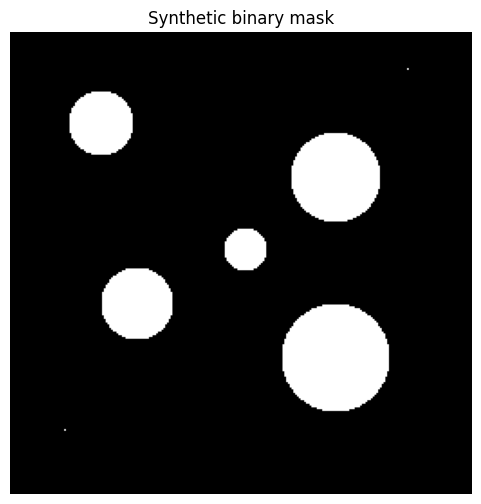

In [4]:
mask = np.zeros((256, 256), dtype=bool)

objects = [
    ((50, 50), 18),
    ((80, 180), 25),
    ((150, 70), 20),
    ((180, 180), 30),
    ((120, 130), 12),
]

for center, radius in objects:
    rr, cc = disk(center, radius, shape=mask.shape)
    mask[rr, cc] = True

# Small noisy objects
mask[20, 220] = True
mask[220, 30] = True

show_image(
    mask,
    "Synthetic binary mask",
    #save_path="../figures/figures_connected_components/synthetic_binary_mask.png"
)

Number of labeled objects: 7


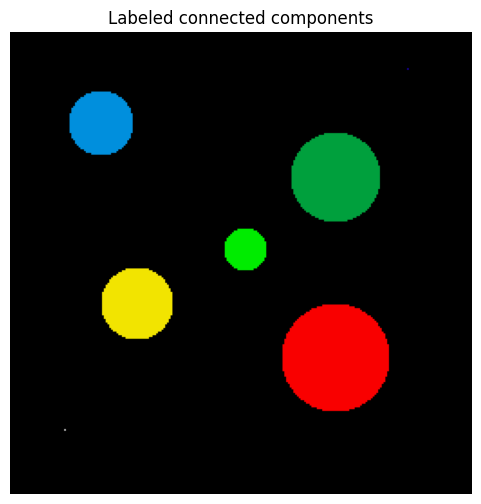

In [5]:
labeled_mask = measure.label(mask, connectivity=2)

print(f"Number of labeled objects: {labeled_mask.max()}")

show_image(
    labeled_mask,
    "Labeled connected components",
    cmap="nipy_spectral",
    save_path="../figures/figures_connected_components/labeled_components.png"
)